In [2]:
from wget import download
from os import path
import pandas as pd


if not path.exists("movies.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/movies.csv")
else:
    print("File already exists, skipping download.")

leer_datos_movies = pd.read_csv("movies.csv")
leer_datos_movies.head()

File already exists, skipping download.


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


__MOVIES__: Titulo de la pelicula. Cuali - Nominal. <br>
__YEAR__: Año de estreno. Cuanti - Discreta. <br>
__GENRE__: Generos de la pelicula/serie. Cuali - Nominal. <br>
__RATING__: Valoracion de la pelicula/serie. Cuanti - Continua. <br>
__ONE-LINE__: Frase corta que describe de que trata. Cuali - Nominal. <br>
__STARS__: Elenco de la pelicula/serie. Cuali - Nominal. <br>
__VOTES__: Cantidad de votos. Cuanti - Discreta. <br>
__RunTime__: Duracion de la pelicula/serie. Cuanti - Discreta. <br>
__Gross__: Recaudacion en taquilla en millones. Cuanti - Continua. <br>

In [3]:
leer_datos_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


In [4]:
leer_datos_movies.isna().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

In [5]:
leer_datos_movies["ONE-LINE"].value_counts()
copia_datos_movies = leer_datos_movies.copy()
# Convierto los valores de la columna "ONE-LINE" que contienen "/nPlot unknown." a NaN
copia_datos_movies["ONE-LINE"] = copia_datos_movies["ONE-LINE"].replace('/nPlot unknown.', pd.NA)

In [6]:
leer_datos_movies["VOTES"].value_counts()

VOTES
7        35
30       31
26       28
32       28
6        27
         ..
6,039     1
7,098     1
5,868     1
6,873     1
911       1
Name: count, Length: 4129, dtype: int64

In [7]:
# Convierto los valores de la columna "VOTES" que contienen comas a enteros y la paso a int
copia_datos_movies["VOTES"] = copia_datos_movies["VOTES"].str.replace(',', '').astype("Int64")
copia_datos_movies.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...",17870,25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...",414849,23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,NaN,NaN


In [8]:
leer_datos_movies["RunTime"].value_counts()

RunTime
24.0     354
60.0     299
30.0     219
23.0     183
25.0     180
        ... 
245.0      1
171.0      1
373.0      1
146.0      1
165.0      1
Name: count, Length: 261, dtype: int64

In [9]:
tiene_decimales = (leer_datos_movies["RunTime"] % 1 != 0).sum()
print(f"¿Hay valores con decimales en la columna 'RunTime'? {tiene_decimales}") #Misma cantidad que NaN

¿Hay valores con decimales en la columna 'RunTime'? 2958


In [10]:
copia_datos_movies["RunTime"] = copia_datos_movies["RunTime"].astype("Int64")

In [11]:
leer_datos_movies["Gross"].value_counts()

Gross
$0.01M     22
$0.02M     16
$0.00M     15
$0.03M     10
$0.04M      9
           ..
$0.21M      1
$2.83M      1
$32.24M     1
$0.24M      1
$10.40M     1
Name: count, Length: 332, dtype: int64

In [12]:
copia_datos_movies["Gross"] = copia_datos_movies["Gross"].str.replace('$', '').str.replace('M', '').astype("Float64")
copia_datos_movies.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121,<NA>
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...",17870,25,<NA>
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44,<NA>
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...",414849,23,<NA>
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,<NA>,<NA>


In [13]:
copia_datos_movies["Gross"].value_counts()

Gross
0.01     22
0.02     16
0.0      15
0.03     10
0.04      9
         ..
0.21      1
2.83      1
32.24     1
0.24      1
10.4      1
Name: count, Length: 332, dtype: Int64

In [14]:
leer_datos_movies["GENRE"].value_counts()

GENRE
\nComedy                                      852
\nAnimation, Action, Adventure                693
\nDrama                                       562
\nDocumentary                                 498
\nCrime, Drama, Mystery                       336
                                             ... 
\nDocumentary, Action, Crime                    1
\nShort, History                                1
\nShort, Reality-TV                             1
\nShort, Action                                 1
\nNews, Reality-TV                              1
Name: count, Length: 510, dtype: int64

In [15]:
#Preporcesar la columna GENRE
copia_datos_movies["GENRE"] = copia_datos_movies["GENRE"].str.replace('\n', '').str.strip()
generos = copia_datos_movies["GENRE"].str.get_dummies(sep=', ')
copia_datos_movies = pd.concat([copia_datos_movies, generos], axis=1)
copia_datos_movies.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross,Action,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
0,Blood Red Sky,(2021),"Action, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,21062,121,<NA>,1,...,0,0,0,0,0,0,0,1,0,0
1,Masters of the Universe: Revelation,(2021– ),"Animation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...",17870,25,<NA>,1,...,0,0,0,0,0,0,0,0,0,0
2,The Walking Dead,(2010–2022),"Drama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...",885805,44,<NA>,0,...,0,0,0,0,0,0,0,1,0,0
3,Rick and Morty,(2013– ),"Animation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...",414849,23,<NA>,0,...,0,0,0,0,0,0,0,0,0,0
4,Army of Thieves,(2021),"Action, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,<NA>,<NA>,<NA>,1,...,0,0,0,0,0,0,0,0,0,0


In [16]:
copia_datos_movies.info()


<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MOVIES       9999 non-null   str    
 1   YEAR         9355 non-null   str    
 2   GENRE        9919 non-null   str    
 3   RATING       8179 non-null   float64
 4   ONE-LINE     9999 non-null   str    
 5   STARS        9999 non-null   str    
 6   VOTES        8179 non-null   Int64  
 7   RunTime      7041 non-null   Int64  
 8   Gross        460 non-null    Float64
 9   Action       9999 non-null   int64  
 10  Adventure    9999 non-null   int64  
 11  Animation    9999 non-null   int64  
 12  Biography    9999 non-null   int64  
 13  Comedy       9999 non-null   int64  
 14  Crime        9999 non-null   int64  
 15  Documentary  9999 non-null   int64  
 16  Drama        9999 non-null   int64  
 17  Family       9999 non-null   int64  
 18  Fantasy      9999 non-null   int64  
 19  Film-Noir    9999

__Existe el preconcepto de que las mejores películas según el público son las__ <br>
__que han logrado mejores recaudaciones. ¿Qué podés decirnos de esta__ <br>
__hipótesis, considerando los datos disponibles? Justificar__ <br>

__Un grupo de expertos en cine asegura que hay una tendencia en los últimos__ <br>
__años a producir películas y series de una duración mayor. ¿Es cierto esto?__ <br>
__Justificar.__ <br>

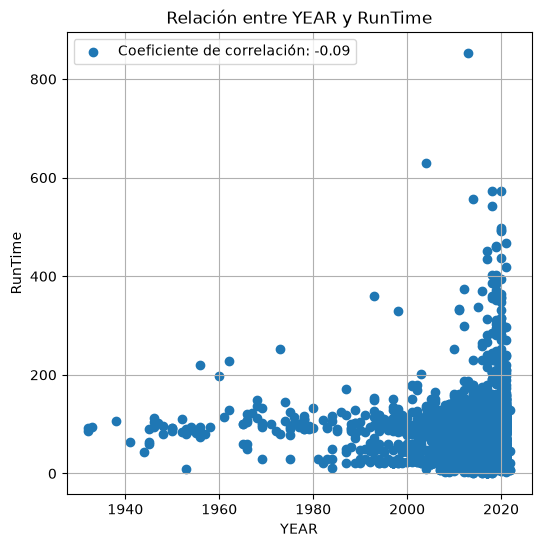

In [17]:
import matplotlib.pyplot as plt
from scipy import stats

# variable1_movies = "Gross"
# variable2_movies = "RATING"
variable1_movies = "YEAR"
variable2_movies = "RunTime"


# Mantener las parejas de datos correspondientes
datos_correlacion_movies = copia_datos_movies[[variable1_movies, variable2_movies]].copy()

# Extraer el año inicial de valores como "(2021–2022)" o "(2021)"
datos_correlacion_movies[variable1_movies] = (datos_correlacion_movies[variable1_movies].astype("string").str.extract(r"(\d{4})", expand=False))

# Convertir ambas variables a valores numéricos
datos_correlacion_movies[variable1_movies] = pd.to_numeric(datos_correlacion_movies[variable1_movies], errors="coerce")
datos_correlacion_movies[variable2_movies] = pd.to_numeric(datos_correlacion_movies[variable2_movies], errors="coerce")

# Eliminar filas que no tengan valores válidos en alguna de las dos variables
datos_correlacion_movies = datos_correlacion_movies.dropna()

datos_col1_movies = datos_correlacion_movies[variable1_movies].to_numpy(dtype=float)
datos_col2_movies = datos_correlacion_movies[variable2_movies].to_numpy(dtype=float)

#coeficiente_correlacion_movies, _ = stats.pearsonr(datos_col1_movies,datos_col2_movies)
coeficiente_correlacion_movies, _ = stats.spearmanr(datos_col1_movies, datos_col2_movies)


plt.figure(figsize=(6, 6))
plt.scatter(datos_col1_movies, datos_col2_movies)
#plt.boxplot([datos_col1_movies, datos_col2_movies], labels=[variable1_movies, variable2_movies])
plt.xlabel(variable1_movies)
plt.ylabel(variable2_movies)
plt.title(f"Relación entre {variable1_movies} y {variable2_movies}")
plt.legend([f"Coeficiente de correlación: {coeficiente_correlacion_movies:.2f}"], loc="upper left")
plt.grid(True)
plt.show()

Se observa una correlación positiva débil, por lo que, aunque existe una leve tendencia a que las películas con mayor <br>
recaudación tengan un rating algo mayor, la relación no es suficientemente fuerte como para afirmar que las películas <br>
mejor valoradas sean necesariamente las que más recaudan.<br>

Por lo tanto, los datos no respaldan la hipótesis de que las películas consideradas mejores por el público sean aquellas <br>
que han logrado mayores recaudaciones. Ademas, se puede ver en grafico.

Se observa una correlacion negativa, por ende no hay una relacion de que en los ultimos años las peliculas y series tengan una duracion mayor. En el grafico se puede ver que muchas peliculas y series entre 2000 y 2020 tienden a tener la misma duracion

<Figure size 600x600 with 0 Axes>

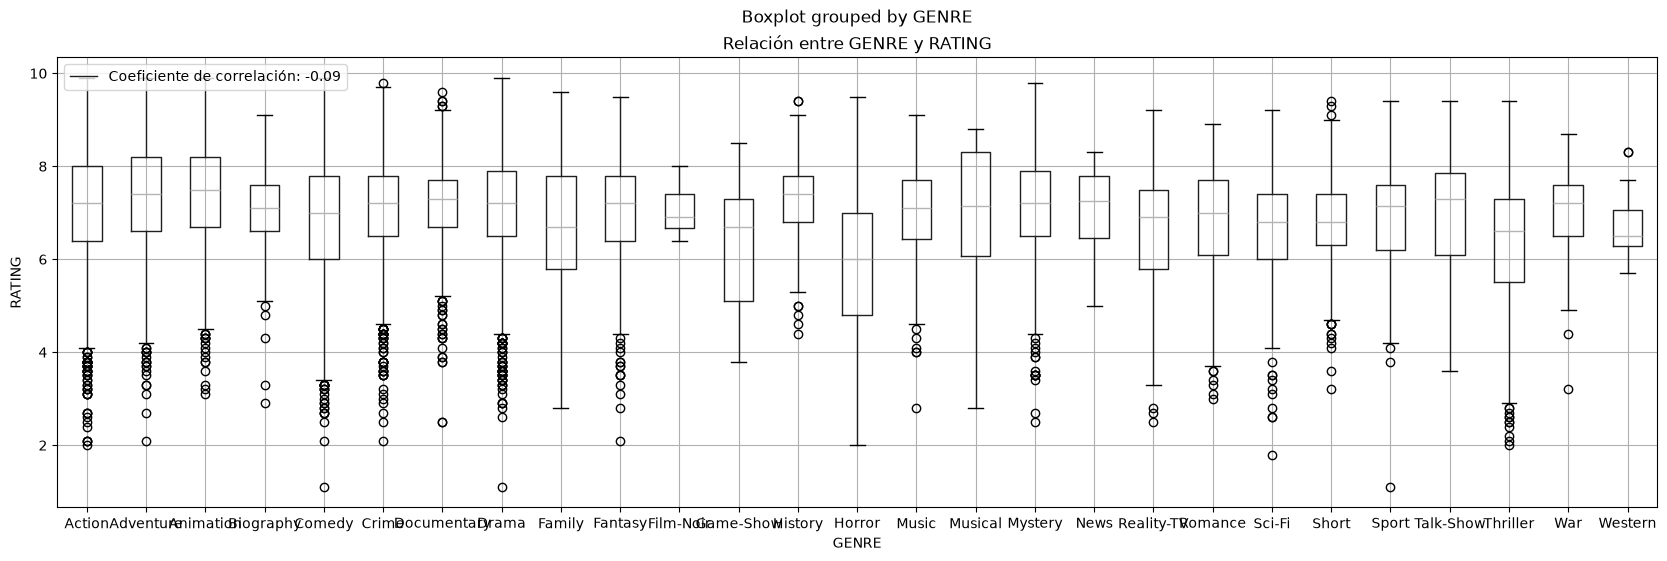

In [18]:
# variable1_movies = "VOTES"
# variable2_movies = "RunTime"
# variable1_movies = "RATING"
# variable2_movies = "VOTES"
variable1_movies = "GENRE"
variable2_movies = "RATING"
datos_generos = []

for genero in generos:
    datos = copia_datos_movies[copia_datos_movies[variable1_movies].str.contains(genero, na=False)][[variable2_movies]].dropna()

    for rating in datos[variable2_movies]:
        datos_generos.append((genero, rating))

df_generos = pd.DataFrame(datos_generos, columns=[variable1_movies, variable2_movies])

    
# Mantener las parejas de datos correspondientes
datos_correlacion_movies = copia_datos_movies[[variable1_movies, variable2_movies]].copy()

# Eliminar filas que no tengan valores válidos en alguna de las dos variables
datos_correlacion_movies = datos_correlacion_movies.dropna()

datos_col1_movies = datos_correlacion_movies[variable1_movies]
datos_col2_movies = datos_correlacion_movies[variable2_movies]

#coeficiente_correlacion_movies, _ = stats.pearsonr(datos_col1_movies,datos_col2_movies)
#coeficiente_correlacion_movies, _ = stats.spearmanr(datos_col1_movies, datos_col2_movies)


plt.figure(figsize=(6, 6))
#plt.scatter(datos_col1_movies, datos_col2_movies)
df_generos.boxplot(column=variable2_movies, by=variable1_movies, figsize=(20, 6))
plt.xlabel(variable1_movies)
plt.ylabel(variable2_movies)
plt.title(f"Relación entre {variable1_movies} y {variable2_movies}")
plt.legend([f"Coeficiente de correlación: {coeficiente_correlacion_movies:.2f}"], loc="upper left")
plt.grid(True)
plt.show()

__Primera hipotesis__: El RATING y VOTES, el numero de rating tambien se debe al numero de votos. Se puede ver que <br>esto no es asi del todo, hay una debil correlacion entre los votos y el rating. Hay una pequeña parte que si <br>cumple esta hipotesis pero es debil para tenerla en cuenta.

__Segunda hipotesis__: El VOTES y RunTime, los votos de la pelicula/serie puede deberse a la duracion. Se puede <br> 
observar una debil relacion entre ambas. Se puede observar una pequeña relacion en los votos bajo y mucha duracion <br> es debil para tenerla en cuenta.

__Tercer hipotesis__: GENRE y RATING, el rating puede tener relacion con el genero de la pelicula/serie. <br>
Se observa que las medianas de los distintos géneros son relativamente similares, ubicándose en general entre 6,5 y <br>7,5 puntos. Si bien algunos géneros presentan valores centrales ligeramente superiores, existe un importante <br>solapamiento entre las distribuciones. También se observan numerosos valores atípicos, principalmente hacia <br>ratings bajos, lo que indica que dentro de un mismo género existen películas con valoraciones muy diferentes. <br> Por lo tanto, no se observa una diferencia marcada en el rating según el género de la película. Esto sugiere <br> que el género, por sí solo, no parece ser un factor determinante para explicar las valoraciones obtenidas.

# Ejercicio 2

In [19]:
import zipfile

if not path.exists("food.zip"):
    download("https://ignaciorlando.github.io/datasets/data-science/food.zip")
else:
    print("File already exists, skipping download.")

with zipfile.ZipFile("food.zip", 'r') as zip_ref:
    zip_ref.extractall()

leer_datos_food = pd.read_csv("food_coded.csv")

leer_datos_food.head()

File already exists, skipping download.


,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


In [20]:
leer_datos_food.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    str    
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    str    
 8   comfort_food_reasons          123 non-null    str    
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_current    

__GPA__: Representa el GPA. Cuanti - Continua <br>
__Gender__ Genero del entrevistado/a. Cuali - Nominal - Dicotomica <br>
__breakfast__: Muestran dos imagenes. 1 si desayuna cereal o 2 si desayuna donas. Cuali - Nominal - Dicotomica <br>
__calories_chicken__: Numeros de calorias del pollo entre 4 opciones. Cuanti - Discreta <br>
__calories_day__: Impotancia de consumir calorias por dia entre 4 opciones. Cuali - Nominal <br>
__calories_scone__: Numeros de calorias del cafe de Starbucks entre 4 opciones. Cuanti - Discreta <br>
__coffe__: Muestran dos imagenes para relacionar la palabra cafe. 1 si es creamy  o 2 si es expresso. Cuali - <br>Nominal - Dicotomica <br>
__comfort_food__: Lista entre 3 y 5 alimentos confortantes. Cuali - Nominal <br>
__comfort_food_reasons__: Razones que llevan a comer comida confortante. Cuali - Nominal <br>
__comfort_food_reasons_coded__: Agarra la primera opcion de la col de arriba y la reprenseta con un numero <br> de una lista. Cuali - Nominal. Preguntar <br>
__cook__: Que tan a menudo comen los estrevistados. Cuali - Nominal <br>
__cuisine__: Que tipo de comida comen. Cuali - Nominal <br>
__diet_current__: dieta actual de los entrevistados. Cuali - Nominal <br>
__diet_current_coded__: Segun la col anterior, la describe con un numero de una lista entre 4 opciones. <br>
__drink__: Muestran dos imagenes. 1 si relaciona drink con judo de naranja o 2 si la relaciona con soda. Cuali - Nominal - Dicotomica <br>


In [21]:
leer_datos_food.isna().sum()

GPA                  2
Gender               0
breakfast            0
calories_chicken     0
calories_day        19
                    ..
type_sports         26
veggies_day          0
vitamins             0
waffle_calories      0
weight               2
Length: 61, dtype: int64

In [22]:
leer_datos_food["GPA"].value_counts()

GPA
3.5           13
3             11
3.2           10
3.7           10
3.3            9
3.4            9
3.6            7
3.9            7
3.8            6
2.8            5
4              4
3.1            3
2.9            2
3.83           2
2.6            2
2.4            1
3.654          1
2.25           1
3.904          1
2.2            1
3.87           1
3.65           1
3.89           1
3.605          1
3.292          1
3.35           1
Personal       1
3.67           1
3.73           1
3.79 bitch     1
2.71           1
3.68           1
3.75           1
3.92           1
Unknown        1
3.77           1
3.63           1
3.882          1
Name: count, dtype: int64

In [23]:
dataset_food_copy = leer_datos_food.copy()
dataset_food_copy["GPA"] = dataset_food_copy["GPA"].replace('Unknown', pd.NA)

In [24]:
dataset_food_copy["comfort_food"].value_counts()

comfort_food
none                                       1
chocolate, chips, ice cream                1
frozen yogurt, pizza, fast food            1
Pizza, Mac and cheese, ice cream           1
Ice cream, chocolate, chips                1
                                          ..
wine. mac and cheese, pizza, ice cream     1
Pizza / Wings / Cheesecake                 1
rice, potato, seaweed soup                 1
Mac n Cheese, Lasagna, Pizza               1
Chocolates, pizza, and Ritz.               1
Name: count, Length: 124, dtype: int64

In [25]:
import re

dataset_food_copy["comfort_food"] = dataset_food_copy["comfort_food"].replace('none', pd.NA)

def procesar_comfort_food(texto):
    if pd.isna(texto):
        return []

    texto = str(texto).strip()

    # Normalizar separadores
    texto = texto.replace(";", ",")
    texto = texto.replace("/", ",")
    
    # Separar "and" cuando aparece después de una coma.
    # Ejemplo: "Chocolates, pizza, and Ritz"
    texto = re.sub(r",\s*and\s+", ",", texto, flags=re.IGNORECASE)

    # Separar por comas
    comidas = texto.split(",")

    # Limpiar cada comida
    comidas = [
        comida.strip().lower()
        for comida in comidas
        if comida.strip()
    ]

    return comidas

dataset_food_copy["comfort_food"] = dataset_food_copy["comfort_food"].apply(procesar_comfort_food)

In [26]:
comidas = dataset_food_copy["comfort_food"].explode().dropna()
frecuencia_comidas = comidas.value_counts()
print(f"La comida más mencionada es '{frecuencia_comidas.idxmax()}' con {frecuencia_comidas.max()} menciones.")

La comida más mencionada es 'ice cream' con 45 menciones.


<Figure size 600x600 with 0 Axes>

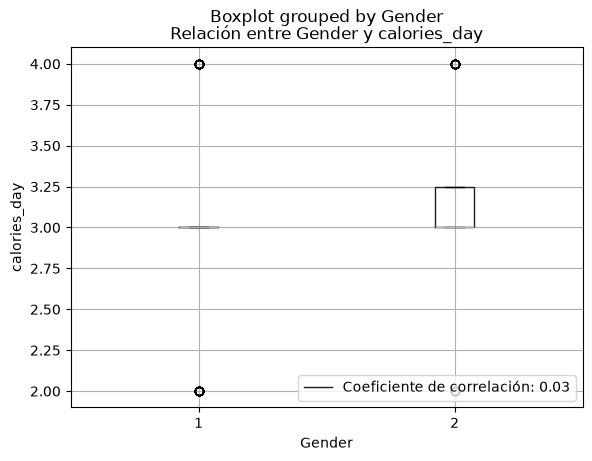

In [28]:
variable1_food = "Gender"
variable2_food = "calories_day"

# Mantener las parejas de datos correspondientes
datos_correlacion_food = dataset_food_copy[[variable1_food, variable2_food]].copy()

# Convertir ambas variables a valores numéricos
datos_correlacion_food[variable1_food] = pd.to_numeric(datos_correlacion_food[variable1_food],errors="coerce")

datos_correlacion_food[variable2_food] = pd.to_numeric(datos_correlacion_food[variable2_food],errors="coerce")

# Eliminar filas que no tengan valores válidos
datos_correlacion_food = datos_correlacion_food.dropna()

# Convertir a arrays
datos_col1_food = datos_correlacion_food[variable1_food].to_numpy(dtype=float)
datos_col2_food = datos_correlacion_food[variable2_food].to_numpy(dtype=float)

# Correlación de Spearman
coeficiente_correlacion_food, _ = stats.spearmanr(datos_col1_food,datos_col2_food)

# Gráfico
plt.figure(figsize=(6, 6))

#plt.scatter(datos_col1_food,datos_col2_food)
datos_correlacion_food.boxplot(column=variable2_food,by=variable1_food)

plt.xlabel(variable1_food)
plt.ylabel(variable2_food)

plt.title(f"Relación entre {variable1_food} y {variable2_food}")

plt.legend([f"Coeficiente de correlación: {coeficiente_correlacion_food:.2f}"])

plt.grid(True)
plt.show()

__Primera hipotesis__: Genre y calories_day. Puede afectar las calorias diarias dependiendo el genero. Se puede observa que no hay relacion al respecto. Por ende esta hipotesis queda descartada.

